**import packages**


In [80]:

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

## read dataset + split train test per flow

In [81]:
ddos_dataset_df = pd.read_csv("ddos_dataset_first_version_clean.csv", low_memory = False)
X = ddos_dataset_df.drop(columns=['label'])
y = ddos_dataset_df[['label']]


In [82]:
# split train test per flow
# TODO replace naming to fit per flow 


X_train, X_test, y_train, y_test = train_test_split(
    X, # X
    y, # y
    stratify = y, # stratify the dataset based on class labels
    train_size = 0.7, # percentage of training set
    random_state = 15 
)


#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them
cols_to_exclude = ['flow_id', 'source_ip', 'destination_ip', 'timestamp', 'simillarhttp'] 

# normalize only selected columns
all_features = X_train.columns.tolist()
cols_to_scale = [col for col in all_features if col not in cols_to_exclude]
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])




In [83]:
#check stratified 
import pandas as pd

# 1. Calculate the normalized value counts (percentages) for both sets
# We use normalize=True to get fractions (0.10) instead of raw counts (100)
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

# 2. Combine them into a single DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Train_Ratio': train_dist,
    'Test_Ratio': test_dist
})

# 3. Calculate the difference to see the error margin
comparison_df['Diff'] = (comparison_df['Train_Ratio'] - comparison_df['Test_Ratio']).abs()

# 4. Display the table (Formatted as percentages)
print("Stratification Check (Class Distribution):")
print(comparison_df.style.format("{:.2%}"))

# 5. Optional: Alert on big discrepancies
# If any class differs by more than 5% (0.05), it might be problematic
threshold = 0.05
bad_splits = comparison_df[comparison_df['Diff'] > threshold]

if not bad_splits.empty:
    print(f"\n⚠️ WARNING: The following classes are poorly stratified (> {threshold:.0%} diff):")
    print(bad_splits.index.tolist())
else:
    print("\n✅ Stratification looks good! (All differences < 5%)")

Stratification Check (Class Distribution):

✅ Stratification looks good! (All differences < 5%)


## show that this is not reasnoble to split per group per flow

In [68]:
#TODO validate not sure this is what requested
# should the split be some src ip in train different src ip in dest or litteraly use groupby and then look only at ip level 
"""
# split train test per flow + normalization
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=14)
groups = ddos_dataset_df[' Source IP']
# get splited dataset, iterate one iteration of generaotr
for train_index, test_index in gss.split(X, y, groups=groups):
    X_train_ip, X_test_ip = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train_ip, y_test_ip = y.iloc[train_index].copy(), y.iloc[test_index].copy()

#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them
cols_to_exclude = ['Flow ID', ' Source IP', ' Destination IP', 'Protocol', ' Timestamp', 'SimillarHTTP','Source Port','Destination Port'] 

# normalize only selected columns
all_features = X_train_ip.columns.tolist()
cols_to_scale = [col for col in all_features if col not in cols_to_exclude]
ip_scaler = StandardScaler()
X_train_ip[cols_to_scale] = ip_scaler.fit_transform(X_train_ip[cols_to_scale])
X_test_ip[cols_to_scale] = ip_scaler.transform(X_test_ip[cols_to_scale])
"""

"\n# split train test per flow + normalization\ngss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=14)\ngroups = ddos_dataset_df[' Source IP']\n# get splited dataset, iterate one iteration of generaotr\nfor train_index, test_index in gss.split(X, y, groups=groups):\n    X_train_ip, X_test_ip = X.iloc[train_index].copy(), X.iloc[test_index].copy()\n    y_train_ip, y_test_ip = y.iloc[train_index].copy(), y.iloc[test_index].copy()\n\n#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them\ncols_to_exclude = ['Flow ID', ' Source IP', ' Destination IP', 'Protocol', ' Timestamp', 'SimillarHTTP','Source Port','Destination Port'] \n\n# normalize only selected columns\nall_features = X_train_ip.columns.tolist()\ncols_to_scale = [col for col in all_features if col not in cols_to_exclude]\nip_scaler = StandardScaler()\nX_train_ip[cols_to_scale] = ip_scaler.fit_transform(X_train_ip[cols_to_scale])\nX_test_ip[cols_to_scale] = ip_scaler.transf

In [69]:
#unsuccessful attemp to use stratifed group
"""
groups = ddos_dataset_df['source_ip']
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=16)
for train_index, test_index in sgkf.split(X, y, groups=groups):
    X_train_ip, X_test_ip = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train_ip, y_test_ip = y.iloc[train_index].copy(), y.iloc[test_index].copy()
    break

#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them
cols_to_exclude = ['flow_id', 'source_ip', 'destination_ip', 'protocol', 'timestamp', 'simillarhttp','source_port','destination_port'] 

# normalize only selected columns
all_features = X_train_ip.columns.tolist()
cols_to_scale = [col for col in all_features if col not in cols_to_exclude]
ip_scaler = StandardScaler()
X_train_ip[cols_to_scale] = ip_scaler.fit_transform(X_train_ip[cols_to_scale])
X_test_ip[cols_to_scale] = ip_scaler.transform(X_test_ip[cols_to_scale])
"""

"\ngroups = ddos_dataset_df['source_ip']\nsgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=16)\nfor train_index, test_index in sgkf.split(X, y, groups=groups):\n    X_train_ip, X_test_ip = X.iloc[train_index].copy(), X.iloc[test_index].copy()\n    y_train_ip, y_test_ip = y.iloc[train_index].copy(), y.iloc[test_index].copy()\n    break\n\n#TODO fix and change according if pca is done and thnk about maybe i want to normalize some of them\ncols_to_exclude = ['flow_id', 'source_ip', 'destination_ip', 'protocol', 'timestamp', 'simillarhttp','source_port','destination_port'] \n\n# normalize only selected columns\nall_features = X_train_ip.columns.tolist()\ncols_to_scale = [col for col in all_features if col not in cols_to_exclude]\nip_scaler = StandardScaler()\nX_train_ip[cols_to_scale] = ip_scaler.fit_transform(X_train_ip[cols_to_scale])\nX_test_ip[cols_to_scale] = ip_scaler.transform(X_test_ip[cols_to_scale])\n"

In [70]:
print(ddos_dataset_df['source_ip'].value_counts(normalize=True).sort_values(ascending=False))



source_ip
172.16.0.5         0.906479
192.168.50.7       0.033782
192.168.50.6       0.019244
192.168.50.8       0.013347
192.168.50.1       0.009818
                     ...   
104.88.52.29       0.000016
204.154.111.120    0.000016
172.217.11.14      0.000016
54.201.6.28        0.000016
52.5.32.71         0.000016
Name: proportion, Length: 216, dtype: float64


/tmp/ipykernel_53/1675828021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette="viridis")


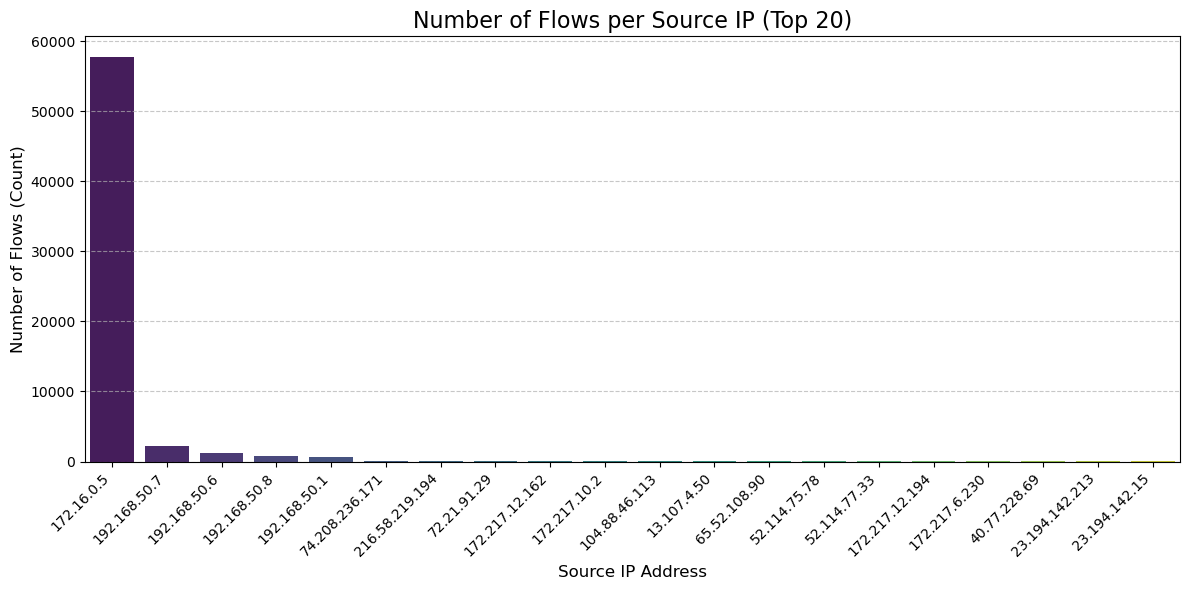

In [72]:
# 1. Aggregate the data (Counting flows per Source IP)
flow_counts = ddos_dataset_df['source_ip'].value_counts().sort_values(ascending=False)

# 2. Plot the top 20 IPs for readability
top_n = 20
plot_data = flow_counts.head(top_n)

# 3. Create the Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette="viridis")
plt.title(f'Number of Flows per Source IP (Top {top_n})', fontsize=16)
plt.xlabel('Source IP Address', fontsize=12)
plt.ylabel('Number of Flows (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [74]:
ip_label_counts = pd.crosstab(ddos_dataset_df['source_ip'], ddos_dataset_df['label'])
print("without specific ip")
print(ip_label_counts.drop("172.16.0.5").sum())
print("specific ip")
print(ip_label_counts.loc["172.16.0.5"])

without specific ip
label
0     5376
1      259
2        4
3        1
4        1
5      316
6        1
7        2
8        0
9        1
10       1
11       1
dtype: int64
specific ip
label
0        0
1     5092
2     5924
3     5909
4     5829
5      493
6     5983
7     5968
8     5480
9     5260
10    5875
11    5985
Name: 172.16.0.5, dtype: int64


## create + train models

In [84]:
# remove unnecessary columns for training 
cols_to_drop = ['flow_id', 'source_ip', 'destination_ip', 'timestamp','simillarhttp']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC


log_reg = LogisticRegression()
log_reg.fit(X_train, y_train.values.ravel())
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train.values.ravel())
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train.values.ravel())


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:

#present results
y_train_log_reg_pred = log_reg.predict(X_train)
y_test_log_reg_pred = log_reg.predict(X_test)
print("log_reg")
print(classification_report(y_train, y_train_log_reg_pred)) 
print(classification_report(y_test, y_test_log_reg_pred)) 

y_train_rfc_pred = rfc.predict(X_train)
y_test_rfc_pred = rfc.predict(X_test)
print("rfc")
print(classification_report(y_train, y_train_rfc_pred)) 
print(classification_report(y_test, y_test_rfc_pred)) 


y_train_dtc_pred = dtr.predict(X_train)
y_test_dtc_pred = dtr.predict(X_test)
print("dtc")
#TODO figure out why conversion is needed
print(classification_report(y_train, y_train_dtc_pred.astype(int))) 
print(classification_report(y_test, y_test_dtc_pred.astype(int))) 



In [ ]:
lsvc = LinearSVC()
lsvc.fit(X_train, y_train.values.ravel())

"""
y_train_lsvc_pred = lsvc.predict(X_train)
y_test_lsvc_pred = lsvc.predict(X_test)
print("lsvc")
print(classification_report(y_train, y_train_lsvc_pred)) 
print(classification_report(y_test, y_test_lsvc_pred)) 
"""

In [59]:
y_train.values.dtype, y_train_dtc_pred.dtype, y_train_rfc_pred.dtype


dtype('int64')